In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn

print("Python:", __import__("sys").version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: 3.11.0 | packaged by Anaconda, Inc. | (main, Mar  1 2023, 18:18:21) [MSC v.1916 64 bit (AMD64)]
Pandas: 2.2.2
NumPy: 1.26.4


In [49]:
df=pd.read_csv("..\\data\\uncleaned data//retail_store_sales_promotions_demand.csv")

In [50]:
df.head(5)

,store_id,product_id,date,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week
0,12,1823,2024-09-19,Home,1902,No,0,17,251,Friday
1,6,1551,2024-12-21,Grocery,2629,Yes,0,14,248,Wednesday
2,40,1015,2024-09-27,Grocery,2488,No,0,25,251,Saturday
3,50,1475,2024-06-16,Home,293,Yes,5,7,470,Tuesday
4,32,1004,2024-12-05,Grocery,2470,Yes,20,37,139,Saturday


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   store_id          2800 non-null   int64 
 1   product_id        2800 non-null   int64 
 2   date              2800 non-null   object
 3   category          2800 non-null   object
 4   price             2800 non-null   int64 
 5   promotion_active  2800 non-null   object
 6   discount_percent  2800 non-null   int64 
 7   units_sold        2800 non-null   int64 
 8   inventory_level   2800 non-null   int64 
 9   day_of_week       2800 non-null   object
dtypes: int64(6), object(4)
memory usage: 218.9+ KB


In [52]:
df.isnull().sum()

store_id            0
product_id          0
date                0
category            0
price               0
promotion_active    0
discount_percent    0
units_sold          0
inventory_level     0
day_of_week         0
dtype: int64

In [53]:
df.shape

(2800, 10)

In [54]:
df.describe()

,store_id,product_id,price,discount_percent,units_sold,inventory_level
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,25.381429,1495.836429,1518.536786,6.844643,26.290000,254.571429
std,14.217981,290.054812,846.448062,9.643473,11.378834,139.007945
min,1.000000,1000.000000,50.000000,0.000000,1.000000,20.000000
25%,13.000000,1242.000000,792.750000,0.000000,17.000000,134.000000
50%,25.000000,1497.500000,1533.000000,0.000000,26.000000,254.500000
75%,38.000000,1750.250000,2246.250000,15.000000,35.000000,376.250000
max,50.000000,2000.000000,3000.000000,30.000000,56.000000,500.000000


In [55]:
df.describe(include="object")

,date,category,promotion_active,day_of_week
count,2800,2800,2800,2800
unique,366,5,2,7
top,2024-02-05,Grocery,Yes,Sunday
freq,16,578,1430,409


In [56]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique()[:20])


store_id
[12  6 40 50 32 46 26  4 22 16 44 42  2 17 14  9 20 13  3 19]

product_id
[1823 1551 1015 1475 1004 1260 1110 1481 1089 1723 1572 1392 1215 1009
 1596 1982 1930 1703 1524 1532]

date
['2024-09-19' '2024-12-21' '2024-09-27' '2024-06-16' '2024-12-05'
 '2024-06-10' '2024-05-28' '2024-07-11' '2024-06-08' '2024-02-21'
 '2024-04-06' '2024-02-29' '2024-04-05' '2024-11-08' '2024-11-21'
 '2024-10-27' '2024-04-26' '2024-07-17' '2024-05-10' '2024-03-30']

category
['Home' 'Grocery' 'Electronics' 'Clothing' 'Personal Care']

price
[1902 2629 2488  293 2470 1923 2150  323 1769  112  295 2134 1773 2515
 1263  113 2403 1071 2522 2935]

promotion_active
['No' 'Yes']

discount_percent
[ 0  5 20 30 15 10]

units_sold
[17 14 25  7 37 10  6 19 26 13 16 34 33 27 51  9 36 22 20 44]

inventory_level
[251 248 470 139 228  35  20 342 408 428 413 158  94  57 210 113 398  44
 151 306]

day_of_week
['Friday' 'Wednesday' 'Saturday' 'Tuesday' 'Monday' 'Thursday' 'Sunday']


In [57]:
df["category"].unique()

array(['Home', 'Grocery', 'Electronics', 'Clothing', 'Personal Care'],
      dtype=object)

In [58]:
df["promotion_active"].unique()

array(['No', 'Yes'], dtype=object)

In [60]:
df["price"].unique().shape

(1850,)

In [22]:
df["store_id"].unique().shape

(50,)

In [61]:
df["date"] = pd.to_datetime(df["date"])

In [62]:
df["day_of_week"] = df["date"].dt.day_name()

In [63]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.day_name()
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

In [64]:
df.head(5)

,store_id,product_id,date,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week,year,month,day,week_of_year
0,12,1823,2024-09-19,Home,1902,No,0,17,251,Thursday,2024,9,19,38
1,6,1551,2024-12-21,Grocery,2629,Yes,0,14,248,Saturday,2024,12,21,51
2,40,1015,2024-09-27,Grocery,2488,No,0,25,251,Friday,2024,9,27,39
3,50,1475,2024-06-16,Home,293,Yes,5,7,470,Sunday,2024,6,16,24
4,32,1004,2024-12-05,Grocery,2470,Yes,20,37,139,Thursday,2024,12,5,49


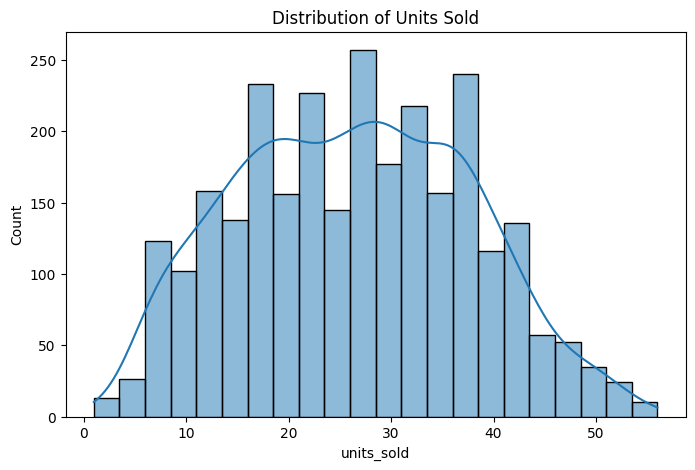

In [65]:
plt.figure(figsize=(8,5))
sns.histplot(df["units_sold"], kde=True)
plt.title("Distribution of Units Sold")
plt.show()

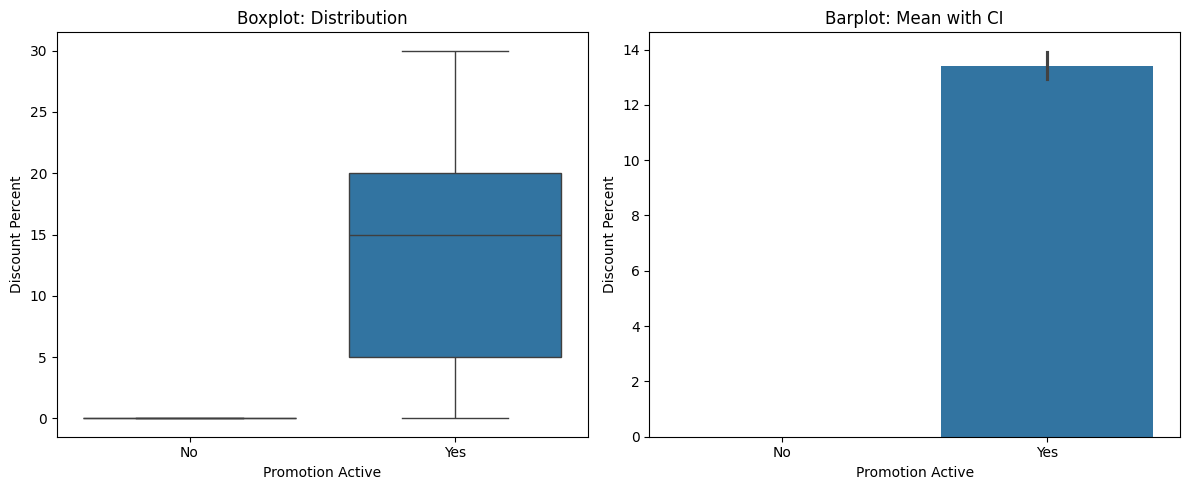

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df,
    x="promotion_active",
    y="discount_percent",
    ax=axes[0]
)
axes[0].set_title("Boxplot: Distribution")

sns.barplot(
    data=df,
    x="promotion_active",
    y="discount_percent",
    ax=axes[1]
)
axes[1].set_title("Barplot: Mean with CI")

for ax in axes:
    ax.set_xlabel("Promotion Active")
    ax.set_ylabel("Discount Percent")

plt.tight_layout()
plt.show()


In [67]:
df.drop("product_id", axis=1, inplace=True)
df.drop("date", axis=1, inplace=True)
df.drop("promotion_active", axis=1, inplace=True)

In [69]:
df.head(3)

,store_id,category,price,discount_percent,units_sold,inventory_level,day_of_week,year,month,day,week_of_year
0,12,Home,1902,0,17,251,Thursday,2024,9,19,38
1,6,Grocery,2629,0,14,248,Saturday,2024,12,21,51
2,40,Grocery,2488,0,25,251,Friday,2024,9,27,39


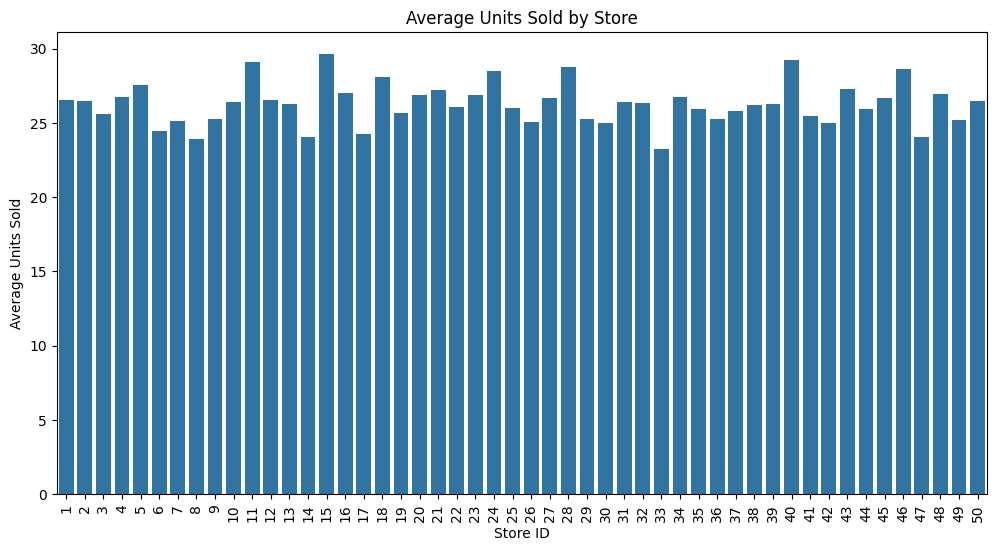

In [34]:
store_demand = (
    df.groupby("store_id")["units_sold"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=store_demand,
    x="store_id",
    y="units_sold"
)

plt.title("Average Units Sold by Store")
plt.xlabel("Store ID")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=90)
plt.show()

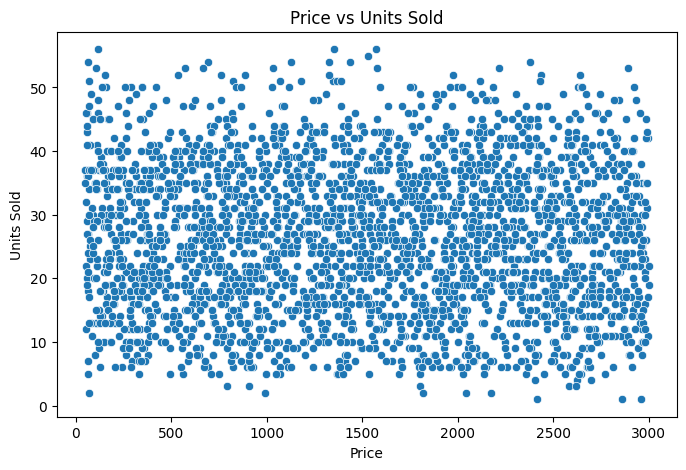

In [38]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="price",
    y="units_sold"
)

plt.title("Price vs Units Sold")
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.show()

In [77]:
df.shape

(2800, 11)

In [71]:
day_mapping = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6
}

df["day_of_week"] = df["day_of_week"].map(day_mapping)

In [73]:
category_mapping = {
    "Home": 0,
    "Grocery": 1,
    "Electronics": 2,
    "Clothing": 3,
    "Personal Care": 4
}

df["category"] = df["category"].map(category_mapping)

In [75]:
correlation = df.corr(numeric_only=True)["units_sold"].sort_values(ascending=False)

print(correlation)

units_sold          1.000000
discount_percent    0.175889
inventory_level     0.063847
month               0.001268
store_id           -0.000680
week_of_year       -0.002042
category           -0.004065
day                -0.006137
day_of_week        -0.006983
price              -0.019616
year                     NaN
Name: units_sold, dtype: float64


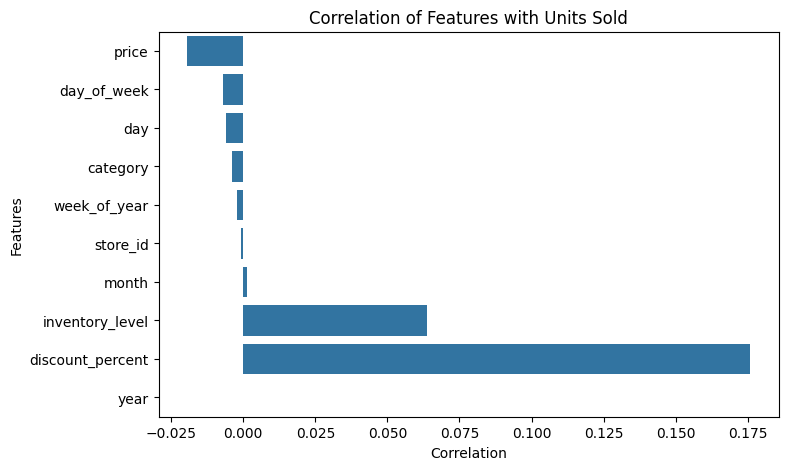

In [78]:
correlation = (
    df.corr(numeric_only=True)["units_sold"]
    .drop("units_sold")
    .sort_values()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=correlation.values,
    y=correlation.index
)

plt.title("Correlation of Features with Units Sold")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

In [79]:
df.head(5)

,store_id,category,price,discount_percent,units_sold,inventory_level,day_of_week,year,month,day,week_of_year
0,12,0,1902,0,17,251,3,2024,9,19,38
1,6,1,2629,0,14,248,5,2024,12,21,51
2,40,1,2488,0,25,251,4,2024,9,27,39
3,50,0,293,5,7,470,6,2024,6,16,24
4,32,1,2470,20,37,139,3,2024,12,5,49


In [81]:
import os

os.makedirs("data/claned data", exist_ok=True)

In [83]:
df.to_csv(
    "../data/cleaned data/clean_data.csv",
    index=False
)